# worked examples

> Each section below is a worked Example (Ex.) addressing a different aspect of this set of utilities.


## Ex.1: diff analysis between Mistral and Datalab on Artusi's first 4 pages

I think this is a good test case — the Artusi title page is unusually hard (ornamental 1891 display type, blackletter-ish capitals, printer's devices), so it stresses glyph recognition far more than body text would. Here's what we see in the diff, grouped by kind of difference.


### House keeping before we start

In [ ]:
#| eval: false

### Check we have pymudf which we will use to show the first page of the pdf
!pip install pymupdf


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
#| eval: false

# We will need both datalab and Mistral keys set here to run this example.
# Check that the api keys for mistral and datalab are in an .env folder. 
# Use load_dotenv to load from a specific file,
# e.g. load_dotenv(Path("~/estravon-workdir/.env").expanduser()) 
import os
check_mistral = os.environ.get("MISTRAL_API_KEY") is not None
check_datalab = os.environ.get("DATALAB_API_KEY") is not None
print("mistral api key is set: " , check_mistral)
print("datalab api key is set: ", check_datalab )

mistral api key is set:  True
datalab api key is set:  True


### Method

#### download the book

In [ ]:
#| eval: false

from estravon_bench.io import get_artusi
pdf_path_artusi=str(get_artusi())

406 pages


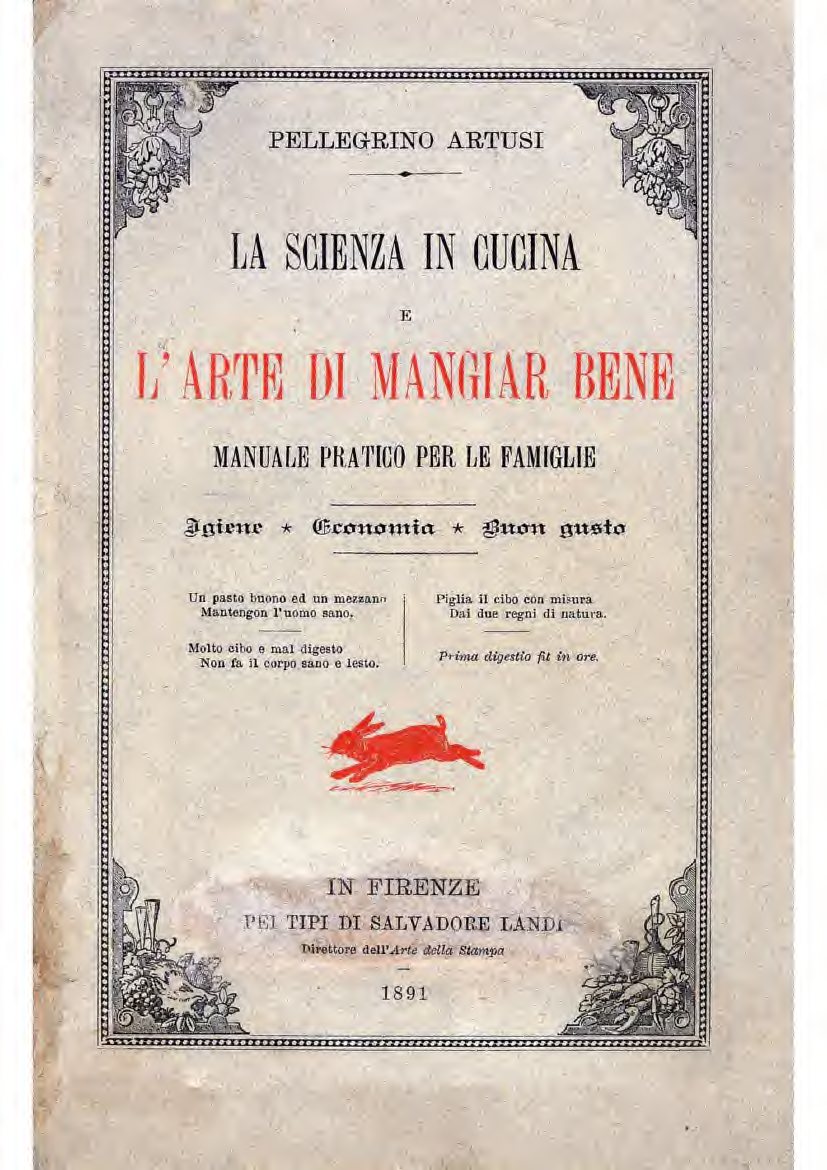

In [ ]:
#| eval: false

import fitz
from IPython.display import Image

doc = fitz.open(pdf_path_artusi)
print(f"{doc.page_count} pages")
pix = doc[0].get_pixmap(dpi=100)
Image(data=pix.tobytes())

In [ ]:
#| eval: false

from estravon_bench.compare import compare

result_mistral = compare(
    pdf_path=pdf_path_artusi,   # public-domain 1891 cookbook -- downloaded/cached on first call
    page_range="1-4",
    engines=["mistral"],   # whichever engines you have configured, you can also list them
    mode="balanced",
)
print(result_mistral.to_markdown_table())

| engine | time (s) | cost (usd) | local | pages | images | status |
|---|---|---|---|---|---|---|
| mistral | 8.06 | $0.0080 | no | 4 | 3 | ok |


In [ ]:
#| eval: false

result_datalab = compare(
    pdf_path=pdf_path_artusi,   # public-domain 1891 cookbook -- downloaded/cached on first call
    page_range="1-4",
    engines=["datalab"],   # whichever engines you have configured
    mode="balanced",
)
print(result_datalab.to_markdown_table())

| engine | time (s) | cost (usd) | local | pages | images | status |
|---|---|---|---|---|---|---|
| datalab | 27.83 | $0.0080 | no | 4 | 2 | ok |


In [ ]:
#| eval: false

# merge the two results together
from estravon_bench.report import ComparisonResultList
combined = ComparisonResultList.merge(result_mistral, result_datalab)

In [ ]:
#| eval: false

# show some of the markdown (more or less the first page)
for r in combined:
    print(f"-----------------> {r.engine} <----------------------")
    print(r.markdown[0:500] if r.ok else f"ERROR: {r.error}")

-----------------> mistral <----------------------
PELLEGRINO ARTUSI

# LA SCIENZA IN CUCINA

E

# L'ARTE DI MANGIAR BENE

# MANUALE PRATICO PER LE FAMIGLIE

Agiene ★ Economia ★ Buon gusto

Un pasto buono ed un mezzano
Mantengon l'uomo sano.

Molto cibo e mal digesto
Non fa il corpo sano e lesto.

Piglia il cibo con misura
Dal due regni di natura.

Prima digestio fit in ore.

![img-0.jpeg](bench_img_001.jpeg)

IN FIRENZE

![img-1.jpeg](bench_img_002.jpeg)

PEI TIPI DI SALVADORE LANDI

Direttore dell'Arte della Stampa

1891

# LA SCIENZA IN CUCIN
-----------------> datalab <----------------------


PELLEGRINO ARTUSI

# LA SCIENZA IN CUCINA

E

## L'ARTE DI MANGIAR BENE

MANUALE PRATICO PER LE FAMIGLIE

Igiene \* Economia \* Buon gusto

Un pasto buono ed un mezzano  
Mantengon l'uomo sano.

Piglia il cibo con misura  
Dai due regni di natura.

Molto cibo e mal digesto  
Non fa il corpo sano e lesto.

*Prima digestio fit in ore.*

![A red ink illustration of a rabbit running to the left.]

### Results


#### Structural / heading policy

Mistral promotes almost anything visually large to `#`: "L'ARTE DI MANGIAR BENE", "MANUALE PRATICO PER LE FAMIGLIE" and even "PROPRIETÀ LETTERARIA" all become H1. Datalab infers a hierarchy instead — `##` for the subtitle, plain paragraph for "MANUALE PRATICO...". The stats confirm it: 8 headings vs 4. Mistral is mapping *type size* to heading level; Datalab is mapping *document role*. For Zotero/RAG chunking that matters a lot — a document where every other line is H1 gives you useless section boundaries.

#### Line-break fidelity

Datalab emits trailing double-spaces to preserve the couplets:

```markdown
Un pasto buono ed un mezzano  
Mantengon l'uomo sano.
```

Mistral uses bare newlines, so those verse pairs collapse into one line when rendered. Datalab also captures the italics (`*Prima digestio fit in ore.*`) that Mistral drops, and escapes the decorative asterisks (`Igiene \* Economia`) so they don't accidentally become emphasis.



#### OCR accuracy — the interesting part

they fail in different ways:

| originale | Mistral | Datalab |
|---|---|---|
| Igiene | "Agiene" X | "Igiene" V |
| Dai due regni | "Dal due" X | "Dai due" V |
| ...sano e lesto | "lesto" V | "lieto" X |
| Pei tipi di S. Landi | "PEI TIPI"| "PER TIPI" X |




Mistral's errors are letterform confusions (I -> A, i -> l) — classic optical failures on ornamental capitals. Datalab's errors are language-model normalisations: "Pei" is archaic Italian printing idiom, so it "corrected" it to the more frequent "PER"; likewise "lesto"→"lieto".

That distinction has real consequences. Optical errors look wrong and get caught. LM-normalisation errors look right and slip through. Worth flagging in a benchmark.

Note also that both engines are internally inconsistent: the same couplet appears twice in these 4 pages, and Mistral writes "Dal" on p1 but "Dai" on p3, while Datalab writes "lieto" then "lesto". So a same-document self-consistency check would be a cheap and quite powerful quality metric to add.




#### Images — the biggest practical difference

Mistral: 3 images, generic alt (`![img-0.jpeg](...)`). Datalab: 2 images, VLM-generated descriptive alt.

Two problems on the Datalab side:

1. It dropped an image Mistral caught (the device between "IN FIRENZE" and the printer's name) — 2 vs 3.
2. It duplicates the description into the body text, sometimes twice:

```markdown
![Decorative flourish or ornament.](bench_img_002.jpg)

A decorative flourish or ornament consisting of a horizontal line with...

Decorative flourish or ornament.
```

That's leaking generated English prose into an Italian document's text stream. The contamination shows up directly in the stats — Datalab's top keywords include `lines`, `decorative`, `flourish`, `ornament`, none of which appear in Artusi. It also inflates word_count 171→227 and fk_grade 10.3→12.6.

So the stats block is **not currently comparable across engines**, because one of them is measuring its own captions. If those numbers are meant to drive quality scoring, either strip alt-text before computing them, or compute them on text-only and figure-text separately.

#### Layout artifacts

Datalab inserts `---` rules where the original has printed rules and page divisions; Mistral ignores them. Neither is wrong — it depends on whether physical layout or logical content only is wanted.


#### Summary judgement: 
Datalab gives richer, better-structured markdown (real hierarchy, breaks, italics, figure descriptions) at the cost of speed, one missed figure, text-stream pollution, and a tendency to silently modernise archaic wording. Mistral is faster and more literal, but flattens structure and needs post-processing for headings.
